# Laboratorio 6 - Etiquetado gramatical y reconocimiento de entidades nombradas 
## Gian Paolo Robelo - 20230117

In [18]:
import os
import re
import glob
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

from sklearn.metrics import precision_recall_fscore_support, classification_report

In [19]:
# Semilla para que la selección aleatoria de oraciones sea reproducible.
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# Carga del modelo preentrenado de spaCy.
nlp = spacy.load("en_core_web_sm")

print("Modelo cargado correctamente.")
print("Versión de spaCy:", spacy.__version__)

Modelo cargado correctamente.
Versión de spaCy: 3.8.14


In [20]:
# Buscar archivos de texto y tablas dentro del entorno de trabajo.

DATASET_DIR = Path(".")

archivos = sorted(
    [
        p for p in DATASET_DIR.rglob("*")
        if p.is_file() and p.suffix.lower() in [".txt", ".csv", ".json", ".xlsx"]
    ]
)

print("Archivos encontrados:")
for archivo in archivos:
    print("-", archivo)

Archivos encontrados:
- gutenberg_novels_dataset.csv


## Identificación de las novelas

El dataset tiene tres novelas clásicas en inglés:

- *Pride and Prejudice*, de Jane Austen, publicada en 1813.
- *Frankenstein*, de Mary Shelley, publicada en 1818.
- *Dracula*, de Bram Stoker, publicada en 1897.

Para cada novela se realizó segmentación en oraciones y tokenización con spaCy. Después se seleccionaron 100 oraciones aleatorias por libro para realizar el análisis POS.

In [21]:

archivos_csv = [p for p in archivos if p.suffix.lower() == ".csv"]

for archivo in archivos_csv:
    print(f"\nArchivo: {archivo}")
    
    df_inspeccion = pd.read_csv(archivo)
    
    print("Dimensiones:", df_inspeccion.shape)
    print("Columnas:", list(df_inspeccion.columns))
    display(df_inspeccion.head())


Archivo: gutenberg_novels_dataset.csv
Dimensiones: (3, 6)
Columnas: ['gutenberg_id', 'title', 'author', 'download_url', 'text_length', 'text']


,gutenberg_id,title,author,download_url,text_length,text
0,1342,Pride and Prejudice,Jane Austen,https://www.gutenberg.org/files/1342/1342-0.txt,728392,*** START OF THE PROJECT GUTENBERG EBOOK 1342 ...
1,84,Frankenstein,Mary Shelley,https://www.gutenberg.org/files/84/84-0.txt,419290,*** START OF THE PROJECT GUTENBERG EBOOK 84 **...
2,345,Dracula,Bram Stoker,https://www.gutenberg.org/files/345/345-0.txt,845805,*** START OF THE PROJECT GUTENBERG EBOOK 345 *...


In [22]:
# Cargar el dataset completo desde el archivo CSV.

archivo_dataset = archivos_csv[0]
df = pd.read_csv(archivo_dataset)

print("Dataset cargado correctamente.")
print("Dimensiones:", df.shape)
print("Columnas:", list(df.columns))

# Mostrar la información principal de cada novela.
display(df[["gutenberg_id", "title", "author", "text_length"]])

Dataset cargado correctamente.
Dimensiones: (3, 6)
Columnas: ['gutenberg_id', 'title', 'author', 'download_url', 'text_length', 'text']


,gutenberg_id,title,author,text_length
0,1342,Pride and Prejudice,Jane Austen,728392
1,84,Frankenstein,Mary Shelley,419290
2,345,Dracula,Bram Stoker,845805


In [23]:
# Verificar que existan tres novelas y que cada una tenga texto.

if len(df) != 3:
    print(f"Advertencia: se encontraron {len(df)} registros en lugar de 3.")
else:
    print("Se encontraron exactamente tres novelas.")

for i, fila in df.iterrows():
    print(f"\nNovela {i + 1}")
    print("Título:", fila["title"])
    print("Autor:", fila["author"])
    print("Longitud registrada:", fila["text_length"])
    print("Longitud real del texto:", len(str(fila["text"])))
    print("Inicio del texto:")
    print(str(fila["text"])[:300])

Se encontraron exactamente tres novelas.

Novela 1
Título: Pride and Prejudice
Autor: Jane Austen
Longitud registrada: 728392
Longitud real del texto: 728392
Inicio del texto:
*** START OF THE PROJECT GUTENBERG EBOOK 1342 ***

                            [Illustration:

                             GEORGE ALLEN
                               PUBLISHER

                        156 CHARING CROSS ROAD
                                LONDON

                             RUSKI

Novela 2
Título: Frankenstein
Autor: Mary Shelley
Longitud registrada: 419290
Longitud real del texto: 419290
Inicio del texto:
*** START OF THE PROJECT GUTENBERG EBOOK 84 ***

Frankenstein;

or, the Modern Prometheus

by Mary Wollstonecraft (Godwin) Shelley

 CONTENTS

 Letter 1
 Letter 2
 Letter 3
 Letter 4
 Chapter 1
 Chapter 2
 Chapter 3
 Chapter 4
 Chapter 5
 Chapter 6
 Chapter 7
 Chapter 8
 Chapter 9
 Chapter 10
 Chapt

Novela 3
Título: Dracula
Autor: Bram Stoker
Longitud registrada: 845805
Longitud real del te

In [24]:
def limpiar_gutenberg(texto):
    """
    Elimina el encabezado y el final estándar de Project Gutenberg.
    """
    texto = str(texto).replace("\r\n", "\n").replace("\r", "\n")
    
    # Eliminar el encabezado de Project Gutenberg.
    patron_inicio = r"\*\*\* START OF (?:THE )?PROJECT GUTENBERG EBOOK.*?\*\*\*"
    texto = re.sub(patron_inicio, "", texto, count=1, flags=re.IGNORECASE | re.DOTALL)
    
    # Eliminar el cierre de Project Gutenberg.
    patron_final = r"\*\*\* END OF (?:THE )?PROJECT GUTENBERG EBOOK.*"
    texto = re.sub(patron_final, "", texto, count=1, flags=re.IGNORECASE | re.DOTALL)
    
    # Normalizar espacios y saltos de línea.
    texto = re.sub(r"[ \t]+", " ", texto)
    texto = re.sub(r"\n{3,}", "\n\n", texto)
    
    return texto.strip()

In [25]:
# Preparar el texto completo de cada novela.
# Se conservan las palabras y los signos de puntuación porque spaCy los utilizará como tokens durante el etiquetado POS y NER.

novelas = {}

for _, fila in df.iterrows():
    titulo = fila["title"]
    texto_limpio = limpiar_gutenberg(fila["text"])
    
    novelas[titulo] = {
        "titulo": titulo,
        "autor": fila["author"],
        "id": fila["gutenberg_id"],
        "texto": texto_limpio
    }

print("Novelas preparadas:")
for titulo, datos in novelas.items():
    print(f"- {titulo}: {len(datos['texto']):,} caracteres")

Novelas preparadas:
- Pride and Prejudice: 721,387 caracteres
- Frankenstein: 419,141 caracteres
- Dracula: 840,765 caracteres


In [26]:
# Segmentar cada novela en oraciones y tokens.
# Se utiliza spaCy únicamente para obtener las oraciones en esta etapa.
# El etiquetado POS y NER se aplicará posteriormente sobre las muestras.

nlp_preparacion = spacy.load("en_core_web_sm")
nlp_preparacion.max_length = 2_000_000

for titulo, datos in novelas.items():
    doc = nlp_preparacion(datos["texto"])
    
    oraciones = [
        sent.text.strip()
        for sent in doc.sents
        if len(sent.text.strip()) > 0
    ]
    
    tokens_totales = [
        token.text
        for token in doc
        if not token.is_space
    ]
    
    datos["oraciones"] = oraciones
    datos["tokens_totales"] = tokens_totales
    datos["num_oraciones"] = len(oraciones)
    datos["num_tokens"] = len(tokens_totales)
    
    print(
        f"{titulo}: "
        f"{datos['num_oraciones']:,} oraciones, "
        f"{datos['num_tokens']:,} tokens"
    )

Pride and Prejudice: 5,754 oraciones, 152,543 tokens
Frankenstein: 3,249 oraciones, 85,881 tokens
Dracula: 8,452 oraciones, 191,530 tokens


In [27]:
# Seleccionar una muestra aleatoria de 100 oraciones por novela.
# La misma muestra se utilizará como base para las secciones de POS.

for titulo, datos in novelas.items():
    cantidad_muestra = min(100, len(datos["oraciones"]))
    
    datos["muestra_oraciones"] = random.sample(
        datos["oraciones"],
        cantidad_muestra
    )
    
    datos["muestra_texto"] = " ".join(datos["muestra_oraciones"])
    
    datos["muestra_tokens"] = [
        token.text
        for token in nlp(datos["muestra_texto"])
        if not token.is_space
    ]
    
    datos["num_muestra_oraciones"] = len(datos["muestra_oraciones"])
    datos["num_muestra_tokens"] = len(datos["muestra_tokens"])

In [28]:
# Crear la tabla comparativa solicitada en la sección 1.

tabla_preparacion = pd.DataFrame([
    {
        "Novela": datos["titulo"],
        "Autor": datos["autor"],
        "Oraciones completas": datos["num_oraciones"],
        "Tokens completos": datos["num_tokens"],
        "Oraciones de muestra": datos["num_muestra_oraciones"],
        "Tokens de muestra": datos["num_muestra_tokens"]
    }
    for datos in novelas.values()
])

display(tabla_preparacion)

,Novela,Autor,Oraciones completas,Tokens completos,Oraciones de muestra,Tokens de muestra
0,Pride and Prejudice,Jane Austen,5754,152543,100,2675
1,Frankenstein,Mary Shelley,3249,85881,100,2641
2,Dracula,Bram Stoker,8452,191530,100,2299


In [29]:
# Aplicar el etiquetado POS a la muestra de cada novela.

docs_muestra = {}

for titulo, datos in novelas.items():
    doc = nlp(datos["muestra_texto"])
    docs_muestra[titulo] = doc
    
    print(
        f"{titulo}: "
        f"{sum(1 for token in doc if not token.is_space):,} tokens etiquetados"
    )

Pride and Prejudice: 2,675 tokens etiquetados
Frankenstein: 2,641 tokens etiquetados
Dracula: 2,299 tokens etiquetados


In [30]:
# Mostrar algunos tokens con sus etiquetas POS universal y Penn Treebank.

for titulo, doc in docs_muestra.items():
    print(f"\n--- {titulo} ---")
    
    ejemplos = [
        (token.text, token.pos_, token.tag_)
        for token in doc
        if not token.is_space
    ][:20]
    
    tabla_ejemplos = pd.DataFrame(
        ejemplos,
        columns=["Token", "POS universal", "Etiqueta Penn Treebank"]
    )
    
    display(tabla_ejemplos)


--- Pride and Prejudice ---


,Token,POS universal,Etiqueta Penn Treebank
0,“,PUNCT,``
1,You,PRON,PRP
2,have,VERB,VBP
3,no,DET,DT
4,regard,NOUN,NN
5,",",PUNCT,","
6,then,ADV,RB
7,",",PUNCT,","
8,for,ADP,IN
9,the,DET,DT



--- Frankenstein ---


,Token,POS universal,Etiqueta Penn Treebank
0,I,PRON,PRP
1,gazed,VERB,VBD
2,on,ADP,IN
3,the,DET,DT
4,picture,NOUN,NN
5,of,ADP,IN
6,my,PRON,PRP$
7,mother,NOUN,NN
8,",",PUNCT,","
9,which,PRON,WDT



--- Dracula ---


,Token,POS universal,Etiqueta Penn Treebank
0,Indeed,ADV,RB
1,",",PUNCT,","
2,I,PRON,PRP
3,am,AUX,VBP
4,writing,VERB,VBG
5,now,ADV,RB
6,",",PUNCT,","
7,with,ADP,IN
8,my,PRON,PRP$
9,book,NOUN,NN


In [31]:
# Calcular la distribución de categorías gramaticales de cada novela.
# Se excluyen los espacios porque no son tokens lingüísticos.

distribuciones_pos = []

for titulo, doc in docs_muestra.items():
    contador_pos = Counter(
        token.pos_
        for token in doc
        if not token.is_space
    )
    
    total_tokens = sum(contador_pos.values())
    
    for categoria, frecuencia in contador_pos.items():
        distribuciones_pos.append({
            "Novela": titulo,
            "POS": categoria,
            "Frecuencia": frecuencia,
            "Porcentaje": 100 * frecuencia / total_tokens
        })

tabla_pos = pd.DataFrame(distribuciones_pos)

# Tabla de frecuencias absolutas.
tabla_pos_pivot = tabla_pos.pivot(
    index="POS",
    columns="Novela",
    values="Frecuencia"
).fillna(0).astype(int)

display(tabla_pos_pivot)

Novela,Dracula,Frankenstein,Pride and Prejudice
POS,,,
ADJ,111,156,141
ADP,207,283,270
ADV,130,109,150
AUX,155,130,190
CCONJ,82,122,92
DET,177,221,170
INTJ,2,3,3
NOUN,298,430,343
NUM,8,7,22


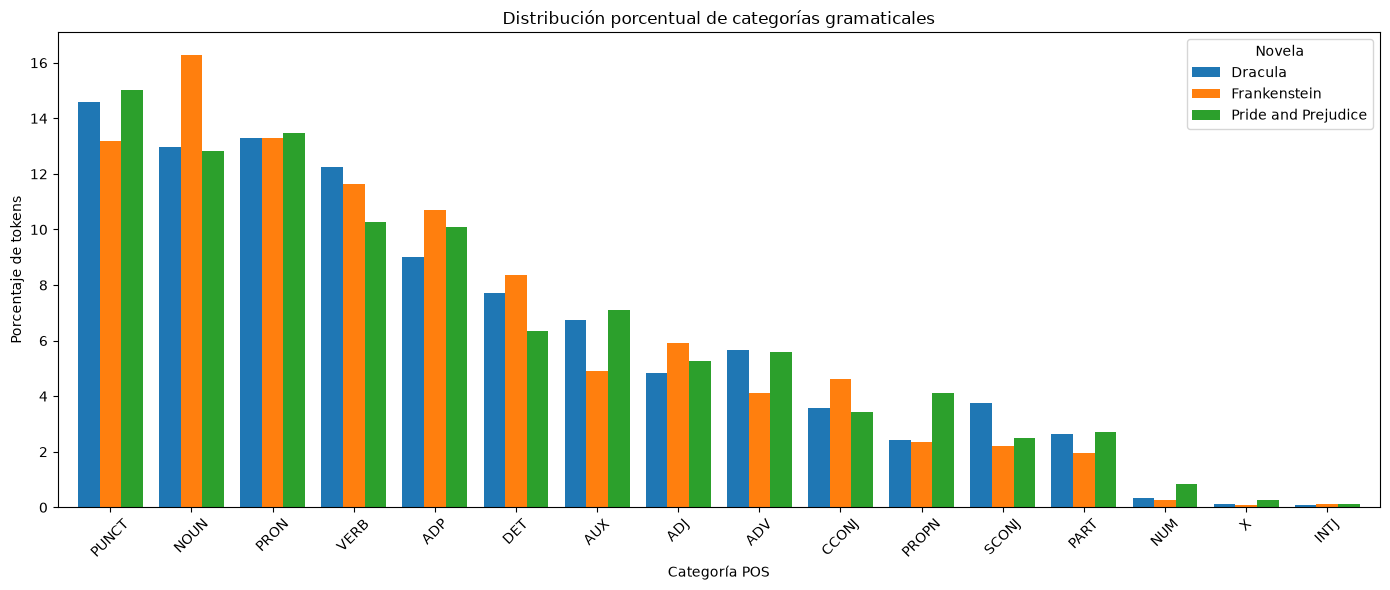

In [32]:
# Gráfico de barras agrupadas para comparar las categorías POS.
# Se utilizan porcentajes para que las novelas sean comparables
# aunque sus muestras tengan diferente número de tokens.

tabla_pos_porcentajes = tabla_pos.pivot(
    index="POS",
    columns="Novela",
    values="Porcentaje"
).fillna(0)

orden_pos = tabla_pos_porcentajes.mean(axis=1).sort_values(
    ascending=False
).index

tabla_pos_porcentajes = tabla_pos_porcentajes.loc[orden_pos]

ax = tabla_pos_porcentajes.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

ax.set_title("Distribución porcentual de categorías gramaticales")
ax.set_xlabel("Categoría POS")
ax.set_ylabel("Porcentaje de tokens")
plt.xticks(rotation=45)
plt.legend(title="Novela")
plt.tight_layout()
plt.show()

In [33]:
# Buscar palabras que reciben más de una etiqueta POS
# en diferentes contextos de las muestras.

usos_palabras = defaultdict(list)

for titulo, doc in docs_muestra.items():
    for token in doc:
        if (
            not token.is_space
            and token.is_alpha
            and len(token.text) > 2
        ):
            palabra = token.text.lower()
            
            inicio = max(0, token.i - 5)
            fin = min(len(doc), token.i + 6)
            
            contexto = " ".join(
                t.text for t in doc[inicio:fin]
                if not t.is_space
            )
            
            usos_palabras[palabra].append({
                "Novela": titulo,
                "Palabra": token.text,
                "POS": token.pos_,
                "Etiqueta": token.tag_,
                "Contexto": contexto
            })

# Conservar palabras que aparecen con al menos dos categorías POS.
palabras_ambiguas = []

for palabra, usos in usos_palabras.items():
    etiquetas = set(uso["POS"] for uso in usos)
    
    if len(etiquetas) >= 2:
        palabras_ambiguas.append({
            "Palabra": palabra,
            "Número de POS": len(etiquetas),
            "POS encontradas": ", ".join(sorted(etiquetas)),
            "Frecuencia": len(usos)
        })

tabla_ambiguas = pd.DataFrame(palabras_ambiguas)

tabla_ambiguas = tabla_ambiguas.sort_values(
    by=["Número de POS", "Frecuencia"],
    ascending=False
)

display(tabla_ambiguas.head(15))

,Palabra,Número de POS,POS encontradas,Frecuencia
3,that,3,"DET, PRON, SCONJ",88
9,but,3,"ADV, CCONJ, SCONJ",43
16,all,3,"ADV, DET, PRON",39
43,before,3,"ADP, ADV, SCONJ",13
26,after,3,"ADP, ADV, SCONJ",11
34,good,3,"ADJ, NOUN, PROPN",11
47,like,3,"ADJ, ADP, VERB",10
64,right,3,"ADJ, ADV, NOUN",5
51,either,3,"CCONJ, DET, PRON",3
2,the,2,"DET, PRON",308


## Análisis de la ambigüedad POS

Las palabras ambiguas reciben etiquetas diferentes dependiendo del contexto en que aparecen. Esto es esperable porque una misma palabra puede funcionar como sustantivo, verbo, adverbio o determinante.

Algunas diferencias pueden deberse a construcciones antiguas del inglés o a usos que no son tan comunes en textos modernos. También pueden aparecer errores cuando una palabra se usa en una expresión fija o como parte de un verbo compuesto.

El tagger no parece fallar de la misma manera en los tres libros. Las diferencias pueden relacionarse con el estilo narrativo, el vocabulario y la época de cada novela. Por eso, las tablas de contextos son importantes para distinguir una ambigüedad real de un error del modelo.

In [34]:
# Seleccionar tres palabras ambiguas y mostrar dos contextos donde reciban etiquetas POS diferentes.

palabras_seleccionadas = []

for _, fila in tabla_ambiguas.iterrows():
    palabra = fila["Palabra"]
    usos = usos_palabras[palabra]
    
    etiquetas_distintas = {}
    
    for uso in usos:
        etiquetas_distintas.setdefault(uso["POS"], uso)
    
    if len(etiquetas_distintas) >= 2:
        palabras_seleccionadas.append(palabra)
    
    if len(palabras_seleccionadas) == 3:
        break

ejemplos_ambiguedad = []

for palabra in palabras_seleccionadas:
    usos = usos_palabras[palabra]
    etiquetas_distintas = {}
    
    for uso in usos:
        etiquetas_distintas.setdefault(uso["POS"], uso)
    
    for uso in list(etiquetas_distintas.values())[:3]:
        ejemplos_ambiguedad.append(uso)

tabla_ambiguedad = pd.DataFrame(ejemplos_ambiguedad)

display(
    tabla_ambiguedad[
        ["Palabra", "Novela", "POS", "Etiqueta", "Contexto"]
    ]
)

,Palabra,Novela,POS,Etiqueta,Contexto
0,that,Pride and Prejudice,SCONJ,IN,"! He really believed that , were it not for"
1,that,Pride and Prejudice,DET,DT,should be forced to have that disagreeable man...
2,That,Pride and Prejudice,PRON,DT,", said aloud,-- “ That will do extremely well ,"
3,but,Pride and Prejudice,CCONJ,CC,"to believe almost anything , but no one else c..."
4,but,Frankenstein,SCONJ,IN,saw around me nothing but a dense and frightfu...
5,but,Dracula,ADV,CC,howling of the wolves was but short . The rays
6,all,Pride and Prejudice,DET,DT,"to be deceived , by all means . “ Ah ,"
7,all,Pride and Prejudice,PRON,DT,have that disagreeable man all to yourself ; b...
8,all,Pride and Prejudice,ADV,RB,"proud . “ You are all kindness , madam ; but"


In [40]:
# seleccionar cinco oraciones consecutivas de la muestra de pride and prejudice

libro_manual = "Pride and Prejudice"

oraciones_muestra_manual = novelas[
    libro_manual
]["muestra_oraciones"]

oraciones_manuales = oraciones_muestra_manual[:5]

print("oraciones seleccionadas para la anotación manual:")

for i, oracion in enumerate(oraciones_manuales, start=1):
    print(f"\nORACIÓN {i}:")
    print(oracion)

    print("\nTOKENS:")
    print([
        token.text
        for token in nlp(oracion)
        if not token.is_space
    ])

oraciones seleccionadas para la anotación manual:

ORACIÓN 1:
“You have no regard, then, for the honour and credit of my nephew!

TOKENS:
['“', 'You', 'have', 'no', 'regard', ',', 'then', ',', 'for', 'the', 'honour', 'and', 'credit', 'of', 'my', 'nephew', '!']

ORACIÓN 2:
He really
believed that, were it not for the inferiority of her connections, he
should be in some danger.

TOKENS:
['He', 'really', 'believed', 'that', ',', 'were', 'it', 'not', 'for', 'the', 'inferiority', 'of', 'her', 'connections', ',', 'he', 'should', 'be', 'in', 'some', 'danger', '.']

ORACIÓN 3:
Only think what an establishment it would
be for one of them.

TOKENS:
['Only', 'think', 'what', 'an', 'establishment', 'it', 'would', 'be', 'for', 'one', 'of', 'them', '.']

ORACIÓN 4:
Everything, however, went on smoothly,
and was finally settled according to Charlotte’s first sketch.

TOKENS:
['Everything', ',', 'however', ',', 'went', 'on', 'smoothly', ',', 'and', 'was', 'finally', 'settled', 'according', 'to', 'Char

In [41]:
# crear la tabla para comparar las etiquetas

filas_anotacion = []

for numero_oracion, oracion in enumerate(oraciones_manuales, start=1):
    doc_oracion = nlp(oracion)

    for posicion, token in enumerate(doc_oracion):
        if not token.is_space:
            filas_anotacion.append({
                "oración": numero_oracion,
                "posición": posicion,
                "token": token.text,
                "pos universal": token.pos_,
                "etiqueta automática": token.tag_,
                "etiqueta manual": ""
            })

tabla_anotacion = pd.DataFrame(filas_anotacion)

display(tabla_anotacion)

,oración,posición,token,pos universal,etiqueta automática,etiqueta manual
0,1,0,“,PUNCT,``,
1,1,1,You,PRON,PRP,
2,1,2,have,VERB,VBP,
3,1,3,no,DET,DT,
4,1,4,regard,NOUN,NN,
...,...,...,...,...,...,...
121,5,53,do,VERB,VBP,
122,5,54,of,ADP,IN,
123,5,55,her,PRON,PRP$,
124,5,56,heart,NOUN,NN,


In [42]:
# etiquetas penn treebank anotadas manualmente

etiquetas_manuales_por_oracion = [
    [
        "``", "PRP", "VBP", "DT", "NN", ",", "RB", ",",
        "IN", "DT", "NN", "CC", "NN", "IN", "PRP$", "NN", "."
    ],
    [
        "PRP", "RB", "VBD", "IN", ",", "VBD", "PRP", "RB",
        "IN", "DT", "NN", "IN", "PRP$", "NNS", ",", "PRP",
        "MD", "VB", "IN", "DT", "NN", "."
    ],
    [
        "RB", "VB", "WDT", "DT", "NN", "PRP", "MD", "VB",
        "IN", "CD", "IN", "PRP", "."
    ],
    [
        "NN", ",", "RB", ",", "VBD", "RP", "RB", ",", "CC",
        "VBD", "RB", "VBN", "VBG", "IN", "NNP", "POS", "JJ",
        "NN", "."
    ],
    [
        "``", "TO", "VB", "PRP", ",", "PRP", "MD", "VB", "TO",
        "VB", "RB", "NN", ",", "CC", "DT", "NN", "RB", "MD",
        "VB", "VBN", "IN", "JJ", "DT", "NN", "IN", "DT", ":",
        "IN", "VBD", "PRP", "VBN", "IN", "NNP", "VBD", "DT",
        "NN", "IN", "PRP", ",", "PRP", "MD", "RB", "VB", "JJR",
        "IN", "PRP$", "NN", "IN", "PRP", "RB", "VBP", "IN",
        "PRP$", "NN", "."
    ]
]

etiquetas_manuales = [
    etiqueta
    for oracion in etiquetas_manuales_por_oracion
    for etiqueta in oracion
]

if len(etiquetas_manuales) != len(tabla_anotacion):
    print("hay un problema con la cantidad de etiquetas")
    print("etiquetas manuales:", len(etiquetas_manuales))
    print("tokens de la tabla:", len(tabla_anotacion))
else:
    tabla_anotacion["etiqueta manual"] = etiquetas_manuales
    print("cantidad de etiquetas correcta:", len(etiquetas_manuales))

cantidad de etiquetas correcta: 126


In [43]:
# comparar las etiquetas automáticas y manuales

tabla_anotacion["coincide"] = (
    tabla_anotacion["etiqueta automática"]
    == tabla_anotacion["etiqueta manual"]
)

coincidencias = tabla_anotacion["coincide"].sum()
total_tokens = len(tabla_anotacion)
porcentaje = 100 * coincidencias / total_tokens

print(f"coincidencias: {coincidencias} de {total_tokens}")
print(f"porcentaje de coincidencia: {porcentaje:.2f}%")

display(
    tabla_anotacion[
        [
            "oración",
            "token",
            "pos universal",
            "etiqueta automática",
            "etiqueta manual",
            "coincide"
        ]
    ]
)

coincidencias: 123 de 126
porcentaje de coincidencia: 97.62%


,oración,token,pos universal,etiqueta automática,etiqueta manual,coincide
0,1,“,PUNCT,``,``,True
1,1,You,PRON,PRP,PRP,True
2,1,have,VERB,VBP,VBP,True
3,1,no,DET,DT,DT,True
4,1,regard,NOUN,NN,NN,True
...,...,...,...,...,...,...
121,5,do,VERB,VBP,VBP,True
122,5,of,ADP,IN,IN,True
123,5,her,PRON,PRP$,PRP$,True
124,5,heart,NOUN,NN,NN,True


## Comparación entre etiquetas pos

Para las cinco oraciones de *Pride and Prejudice* se analizaron 126 tokens. La anotación manual coincidió con la etiqueta automática en 123 casos, a un 97.62%.

El tagset universal identifica categorías generales como verbo, sustantivo, pronombre o determinante. En cambio, Penn Treebank proporciona información más específica. Por ejemplo, `VB` representa un verbo en forma base, `VBD` un verbo en pasado y `VBP` un verbo en presente. De forma similar, `PRP` identifica pronombres personales, mientras que `PRP$` identifica posesivos.

Los tres desacuerdos encontrados se relacionan principalmente con decisiones dependientes del contexto. Algunas palabras pueden interpretarse de forma distinta según su función dentro de la oración, especialmente en expresiones verbales o construcciones antiguas. En general, el resultado muestra que el tagger tuvo un desempeño alto en este fragmento.

In [44]:
# comprobar el resultado de la anotación manual

coincidencias = tabla_anotacion["coincide"].sum()
total_tokens = len(tabla_anotacion)

print(f"coincidencias: {coincidencias} de {total_tokens}")
print(f"porcentaje de coincidencia: {100 * coincidencias / total_tokens:.2f}%")

desacuerdos_pos = tabla_anotacion[
    ~tabla_anotacion["coincide"]
]

display(desacuerdos_pos)

coincidencias: 123 de 126
porcentaje de coincidencia: 97.62%


,oración,posición,token,pos universal,etiqueta automática,etiqueta manual,coincide
41,3,2,what,PRON,WP,WDT,False
92,5,22,such,DET,PDT,JJ,False
101,5,31,persuaded,VERB,VBD,VBN,False


In [46]:
# preparar fragmentos representativos para ner

fragmentos_ner = {}

texto_pride = novelas["Pride and Prejudice"]["texto"]
texto_frankenstein = novelas["Frankenstein"]["texto"]
texto_dracula = novelas["Dracula"]["texto"]

inicio_pride = re.search(
    r"it\s+is\s+a\s+truth\s+universally\s+acknowledged",
    texto_pride,
    flags=re.IGNORECASE
)

inicio_frankenstein = re.search(
    r"letter\s+1\s*\n+\s*_to\s+mrs\.\s+saville",
    texto_frankenstein,
    flags=re.IGNORECASE
)

inicio_dracula = re.search(
    r"(?im)^chapter\s+i\s*\n+"
    r"\s*jonathan\s+harker[’']s\s+journal\s*\n+"
    r"\s*\(?_?kept\s+in\s+shorthand",
    texto_dracula
)

if inicio_pride is None:
    raise ValueError("no se encontró el inicio narrativo de pride and prejudice.")

if inicio_frankenstein is None:
    raise ValueError("no se encontró el inicio narrativo de frankenstein.")

if inicio_dracula is None:
    raise ValueError(
        "no se encontró el inicio narrativo real de dracula."
    )

fragmentos_ner["Pride and Prejudice"] = texto_pride[
    inicio_pride.start():
][:30000]

fragmentos_ner["Frankenstein"] = texto_frankenstein[
    inicio_frankenstein.start():
][:30000]

fragmentos_ner["Dracula"] = texto_dracula[
    inicio_dracula.start():
][:30000]

for titulo, fragmento in fragmentos_ner.items():
    print(f"\n--- {titulo} ---")
    print("caracteres:", len(fragmento))
    print(fragmento[:500])


--- Pride and Prejudice ---
caracteres: 30000
It is a truth universally acknowledged, that a single man in possession
of a good fortune must be in want of a wife.

However little known the feelings or views of such a man may be on his
first entering a neighbourhood, this truth is so well fixed in the minds
of the surrounding families, that he is considered as the rightful
property of some one or other of their daughters.

“My dear Mr. Bennet,” said his lady to him one day, “have you heard that
Netherfield Park is let at last?”

Mr. Bennet r

--- Frankenstein ---
caracteres: 30000
Letter 1

_To Mrs. Saville, England._

St. Petersburgh, Dec. 11th, 17—.

You will rejoice to hear that no disaster has accompanied the
commencement of an enterprise which you have regarded with such evil
forebodings. I arrived here yesterday, and my first task is to assure
my dear sister of my welfare and increasing confidence in the success
of my undertaking.

I am already far north of London, and as I walk 

In [47]:
# aplicar ner a los fragmentos seleccionados

docs_ner = {}
resumen_ner = []
filas_distribucion_ner = []

for titulo, fragmento in fragmentos_ner.items():
    doc_ner = nlp(fragmento)
    docs_ner[titulo] = doc_ner

    entidades = [
        entidad
        for entidad in doc_ner.ents
        if entidad.text.strip()
    ]

    conteo_tipos = Counter(
        entidad.label_
        for entidad in entidades
    )

    resumen_ner.append({
        "novela": titulo,
        "tokens analizados": sum(
            1 for token in doc_ner if not token.is_space
        ),
        "entidades totales": len(entidades),
        "densidad por 100 tokens": (
            100 * len(entidades)
            / sum(1 for token in doc_ner if not token.is_space)
        )
    })

    for tipo, frecuencia in conteo_tipos.items():
        filas_distribucion_ner.append({
            "novela": titulo,
            "tipo": tipo,
            "frecuencia": frecuencia
        })

tabla_resumen_ner = pd.DataFrame(resumen_ner)

tabla_distribucion_ner = pd.DataFrame(
    filas_distribucion_ner
)

tabla_distribucion_ner_pivot = (
    tabla_distribucion_ner
    .pivot(
        index="tipo",
        columns="novela",
        values="frecuencia"
    )
    .fillna(0)
    .astype(int)
)

display(tabla_resumen_ner)
display(tabla_distribucion_ner_pivot)

,novela,tokens analizados,entidades totales,densidad por 100 tokens
0,Pride and Prejudice,6691,283,4.229562
1,Frankenstein,6087,110,1.807130
2,Dracula,6485,151,2.328450


novela,Dracula,Frankenstein,Pride and Prejudice
tipo,,,
CARDINAL,21,21,34
DATE,12,28,20
FAC,5,0,4
GPE,20,13,13
LANGUAGE,1,2,0
LOC,10,4,0
MONEY,0,0,1
NORP,16,2,1
ORDINAL,3,7,12


In [48]:
# obtener las entidades más frecuentes por novela

filas_entidades_frecuentes = []

for titulo, doc_ner in docs_ner.items():
    personas = Counter(
        entidad.text.strip()
        for entidad in doc_ner.ents
        if entidad.label_ == "PERSON"
        and entidad.text.strip()
    )

    lugares = Counter(
        entidad.text.strip()
        for entidad in doc_ner.ents
        if entidad.label_ in ["GPE", "LOC"]
        and entidad.text.strip()
    )

    for entidad, frecuencia in personas.most_common(10):
        filas_entidades_frecuentes.append({
            "novela": titulo,
            "tipo": "PERSON",
            "entidad": entidad,
            "frecuencia": frecuencia
        })

    for entidad, frecuencia in lugares.most_common(10):
        filas_entidades_frecuentes.append({
            "novela": titulo,
            "tipo": "GPE/LOC",
            "entidad": entidad,
            "frecuencia": frecuencia
        })

tabla_entidades_frecuentes = pd.DataFrame(
    filas_entidades_frecuentes
)

display(tabla_entidades_frecuentes)

,novela,tipo,entidad,frecuencia
0,Pride and Prejudice,PERSON,Bingley,33
1,Pride and Prejudice,PERSON,Bennet,27
2,Pride and Prejudice,PERSON,Darcy,14
3,Pride and Prejudice,PERSON,Long,10
4,Pride and Prejudice,PERSON,Jane,10
5,Pride and Prejudice,PERSON,Lizzy,9
6,Pride and Prejudice,PERSON,Elizabeth,9
7,Pride and Prejudice,PERSON,George Allen,7
8,Pride and Prejudice,PERSON,Mary,5
9,Pride and Prejudice,PERSON,Hurst,5


## Análisis de entidades nombradas

El modelo detectó 283 entidades en *Pride and Prejudice*, 110 en *Frankenstein* y 151 en *Dracula*. Las densidades fueron de 4.23, 1.81 y 2.33 entidades por cada 100 tokens, respectivamente.

*Pride and Prejudice* presentó la mayor densidad y la mayor cantidad de entidades PERSON. Esto coincide con una narración centrada en personajes, relaciones familiares y conversaciones sociales.

En *Frankenstein* se observó la menor densidad de entidades. El fragmento contiene más reflexión, descripción y referencias a viajes que nombres propios.

En *Dracula* aparecen más referencias geográficas, nacionalidades y lugares. Sin embargo, el modelo también cometió errores, por ejemplo al clasificar lugares como personas o nombres de personajes como ubicaciones. Esto muestra que las entidades poco frecuentes y el lenguaje literario pueden confundir al modelo.

In [49]:
# seleccionar cinco oraciones consecutivas para el esquema bio

doc_bio = docs_ner["Pride and Prejudice"]

oraciones_bio = [
    sent.text.strip()
    for sent in doc_bio.sents
    if sent.text.strip()
][:5]

texto_bio = " ".join(oraciones_bio)

print("oraciones seleccionadas para bio:")

for i, oracion in enumerate(oraciones_bio, start=1):
    print(f"\nORACIÓN {i}:")
    print(oracion)

doc_bio = nlp(texto_bio)

print("\nentidades detectadas por spacy:")

for entidad in doc_bio.ents:
    print(f"{entidad.text!r} -> {entidad.label_}")

oraciones seleccionadas para bio:

ORACIÓN 1:
It is a truth universally acknowledged, that a single man in possession
of a good fortune must be in want of a wife.

ORACIÓN 2:
However little known the feelings or views of such a man may be on his
first entering a neighbourhood, this truth is so well fixed in the minds
of the surrounding families, that he is considered as the rightful
property of some one or other of their daughters.

ORACIÓN 3:
“My dear Mr. Bennet,” said his lady to him one day, “have you heard that
Netherfield Park is let at last?”

Mr. Bennet replied that he had not.

ORACIÓN 4:
“But it is,” returned she; “for Mrs. Long has just been here, and she
told me all about it.”

ORACIÓN 5:
Mr. Bennet made no answer.

entidades detectadas por spacy:
'first' -> ORDINAL
'some one' -> CARDINAL
'Bennet' -> PERSON
'one day' -> DATE
'Netherfield Park' -> FAC
'Bennet' -> PERSON
'Long' -> PERSON
'Bennet' -> PERSON


In [50]:
# construir las etiquetas bio corregidas manualmente

tokens_bio = [
    token
    for token in doc_bio
    if not token.is_space
]

etiquetas_bio_corregidas = [
    "O"
    for _ in tokens_bio
]


def marcar_entidad(tokens, etiquetas, secuencia, tipo):
    longitud = len(secuencia)

    for i in range(len(tokens) - longitud + 1):
        tokens_actuales = [
            token.text
            for token in tokens[i:i + longitud]
        ]

        if tokens_actuales == secuencia:
            etiquetas[i] = f"B-{tipo}"

            for j in range(1, longitud):
                etiquetas[i + j] = f"I-{tipo}"


# corregir nombres de personas incompletos
marcar_entidad(
    tokens_bio,
    etiquetas_bio_corregidas,
    ["Mr.", "Bennet"],
    "PERSON"
)

marcar_entidad(
    tokens_bio,
    etiquetas_bio_corregidas,
    ["Mrs.", "Long"],
    "PERSON"
)

# conservar netherfield park como una entidad de tipo instalación
marcar_entidad(
    tokens_bio,
    etiquetas_bio_corregidas,
    ["Netherfield", "Park"],
    "FAC"
)

tabla_bio = pd.DataFrame({
    "token": [
        token.text
        for token in tokens_bio
    ],
    "etiqueta bio": etiquetas_bio_corregidas
})

display(tabla_bio)

,token,etiqueta bio
0,It,O
1,is,O
2,a,O
3,truth,O
4,universally,O
...,...,...
140,Bennet,I-PERSON
141,made,O
142,no,O
143,answer,O


## Esquema bio

Se seleccionaron cinco oraciones consecutivas de *Pride and Prejudice* y se asignó una etiqueta BIO a cada token.

Se corrigieron algunos errores evidentes del modelo. Por ejemplo, `Mr. Bennet` y `Mrs. Long` fueron tratados como entidades PERSON completas, mientras que `Netherfield Park` se conservó como una entidad FAC. Las detecciones incorrectas como `first`, `some one` y `one day` fueron marcadas como `O`.

La etiqueta `B-` indica el inicio de una entidad y `I-` indica la continuación. Los tokens que no pertenecen a ninguna entidad reciben la etiqueta `O`.

In [51]:
# seleccionar veinte oraciones para construir el gold standard

oraciones_evaluacion = {}

for titulo, texto in fragmentos_ner.items():
    doc_evaluacion = nlp(texto)

    oraciones = [
        sent.text.strip()
        for sent in doc_evaluacion.sents
        if sent.text.strip()
    ]

    oraciones_narrativas = [
        oracion
        for oracion in oraciones
        if len(re.findall(r"[A-Za-z]+", oracion)) >= 5
    ]

    oraciones_evaluacion[titulo] = oraciones_narrativas[:20]

    print("\n" + "=" * 80)
    print(titulo)
    print("=" * 80)

    for i, oracion in enumerate(
        oraciones_evaluacion[titulo],
        start=1
    ):
        print(f"{i}: {oracion}")


Pride and Prejudice
1: It is a truth universally acknowledged, that a single man in possession
of a good fortune must be in want of a wife.
2: However little known the feelings or views of such a man may be on his
first entering a neighbourhood, this truth is so well fixed in the minds
of the surrounding families, that he is considered as the rightful
property of some one or other of their daughters.
3: “My dear Mr. Bennet,” said his lady to him one day, “have you heard that
Netherfield Park is let at last?”

Mr. Bennet replied that he had not.
4: “But it is,” returned she; “for Mrs. Long has just been here, and she
told me all about it.”
5: Mr. Bennet made no answer.
6: “Do not you want to know who has taken it?” cried his wife, impatiently.
7: “_You_ want to tell me, and I have no objection to hearing it.”
8: [Illustration:

“He came down to see the place”

[_Copyright 1894 by George Allen._]]
9: “Why, my dear, you must know, Mrs. Long says that Netherfield is taken
by a young man o

In [52]:
# preparar los documentos de evaluación

docs_evaluacion = {}

for titulo, oraciones in oraciones_evaluacion.items():
    texto_evaluacion = " ".join(oraciones)
    docs_evaluacion[titulo] = nlp(texto_evaluacion)

In [53]:
# gold standard manual de entidades

gold_manual = {
    "Pride and Prejudice": [
        ("Mr. Bennet", "PERSON"),
        ("Netherfield Park", "FAC"),
        ("Mr. Bennet", "PERSON"),
        ("Mrs. Long", "PERSON"),
        ("Mr. Bennet", "PERSON"),
        ("George Allen", "PERSON"),
        ("Mrs. Long", "PERSON"),
        ("Netherfield", "GPE"),
        ("England", "GPE"),
        ("Monday", "DATE"),
        ("Mr. Morris", "PERSON"),
        ("Michaelmas", "DATE"),
        ("next week", "DATE"),
        ("Bingley", "PERSON"),
        ("Mr. Bennet", "PERSON"),
        ("Mr. Bingley", "PERSON")
    ],

    "Frankenstein": [
        ("Mrs. Saville", "PERSON"),
        ("England", "GPE"),
        ("St. Petersburgh", "GPE"),
        ("Dec. 11th, 17—", "DATE"),
        ("London", "GPE"),
        ("Petersburgh", "GPE"),
        ("Margaret", "PERSON"),
        ("North Pacific Ocean", "LOC"),
        ("Uncle Thomas", "PERSON")
    ],

    "Dracula": [
        ("JONATHAN HARKER’S JOURNAL", "WORK_OF_ART"),
        ("Bistritz", "GPE"),
        ("Munich", "GPE"),
        ("8:35 P. M.", "TIME"),
        ("1st May", "DATE"),
        ("Vienna", "GPE"),
        ("6:46", "TIME"),
        ("Buda-Pesth", "GPE"),
        ("Danube", "LOC"),
        ("Turkish", "NORP"),
        ("Klausenburgh", "GPE"),
        ("Hotel Royale", "FAC"),
        ("Mina", "PERSON"),
        ("paprika hendl", "PRODUCT"),
        ("Carpathians", "LOC"),
        ("German", "LANGUAGE"),
        ("London", "GPE"),
        ("British Museum", "ORG"),
        ("Transylvania", "GPE"),
        ("Moldavia", "GPE"),
        ("Bukovina", "GPE"),
        ("Carpathian mountains", "LOC"),
        ("Europe", "LOC"),
        ("Castle Dracula", "FAC"),
        ("Ordnance Survey", "ORG"),
        ("Bistritz", "GPE"),
        ("Count Dracula", "PERSON"),
        ("Mina", "PERSON"),
        ("Transylvania", "GPE"),
        ("Saxons", "NORP"),
        ("Wallachs", "NORP"),
        ("Dacians", "NORP"),
        ("Magyars", "NORP"),
        ("Szekelys", "NORP"),
        ("Attila", "PERSON"),
        ("Huns", "NORP"),
        ("Magyars", "NORP"),
        ("eleventh century", "DATE"),
        ("Huns", "NORP"),
        ("Carpathians", "LOC")
    ]
}

for titulo, entidades in gold_manual.items():
    print(f"{titulo}: {len(entidades)} entidades manuales")

Pride and Prejudice: 16 entidades manuales
Frankenstein: 9 entidades manuales
Dracula: 40 entidades manuales


In [55]:
# convertir las entidades manuales en spans de tokens

# localizar entidades aunque tengan espacios o saltos de línea distintos

def obtener_gold_token_spans(doc, entidades):
    spans = []
    posicion_busqueda = 0

    for texto_entidad, etiqueta in entidades:
        patron = re.escape(texto_entidad)
        patron = patron.replace(r"\ ", r"\s+")

        coincidencia = re.search(
            patron,
            doc.text[posicion_busqueda:],
            flags=re.IGNORECASE
        )

        if coincidencia is None:
            print(f"no se encontró: {texto_entidad!r}")
            continue

        inicio = (
            posicion_busqueda
            + coincidencia.start()
        )

        fin = (
            posicion_busqueda
            + coincidencia.end()
        )

        span = doc.char_span(
            inicio,
            fin,
            label=etiqueta,
            alignment_mode="expand"
        )

        if span is not None:
            spans.append((
                span.start,
                span.end,
                etiqueta
            ))

        posicion_busqueda = fin

    return spans


def obtener_pred_token_spans(doc):
    return [
        (entidad.start, entidad.end, entidad.label_)
        for entidad in doc.ents
    ]


def calcular_metricas_token(gold_spans, pred_spans):
    gold_tokens = {
        (indice, etiqueta)
        for inicio, fin, etiqueta in gold_spans
        for indice in range(inicio, fin)
    }

    pred_tokens = {
        (indice, etiqueta)
        for inicio, fin, etiqueta in pred_spans
        for indice in range(inicio, fin)
    }

    verdaderos_positivos = len(
        gold_tokens & pred_tokens
    )

    falsos_positivos = len(
        pred_tokens - gold_tokens
    )

    falsos_negativos = len(
        gold_tokens - pred_tokens
    )

    precision = (
        verdaderos_positivos
        / (verdaderos_positivos + falsos_positivos)
        if verdaderos_positivos + falsos_positivos
        else 0
    )

    recall = (
        verdaderos_positivos
        / (verdaderos_positivos + falsos_negativos)
        if verdaderos_positivos + falsos_negativos
        else 0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if precision + recall
        else 0
    )

    return precision, recall, f1


def calcular_metricas_entidad(gold_spans, pred_spans):
    gold_entidades = set(gold_spans)
    pred_entidades = set(pred_spans)

    verdaderos_positivos = len(
        gold_entidades & pred_entidades
    )

    falsos_positivos = len(
        pred_entidades - gold_entidades
    )

    falsos_negativos = len(
        gold_entidades - pred_entidades
    )

    precision = (
        verdaderos_positivos
        / (verdaderos_positivos + falsos_positivos)
        if verdaderos_positivos + falsos_positivos
        else 0
    )

    recall = (
        verdaderos_positivos
        / (verdaderos_positivos + falsos_negativos)
        if verdaderos_positivos + falsos_negativos
        else 0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if precision + recall
        else 0
    )

    return precision, recall, f1


resultados_evaluacion = []

for titulo, doc in docs_evaluacion.items():
    gold_spans = obtener_gold_token_spans(
        doc,
        gold_manual[titulo]
    )

    pred_spans = obtener_pred_token_spans(doc)

    precision, recall, f1 = calcular_metricas_token(
        gold_spans,
        pred_spans
    )

    resultados_evaluacion.append({
        "novela": titulo,
        "evaluación": "token",
        "precisión": precision,
        "recall": recall,
        "f1": f1
    })

    precision, recall, f1 = calcular_metricas_entidad(
        gold_spans,
        pred_spans
    )

    resultados_evaluacion.append({
        "novela": titulo,
        "evaluación": "entidad completa",
        "precisión": precision,
        "recall": recall,
        "f1": f1
    })

tabla_evaluacion = pd.DataFrame(
    resultados_evaluacion
)

display(tabla_evaluacion)

,novela,evaluación,precisión,recall,f1
0,Pride and Prejudice,token,0.444444,0.592593,0.507937
1,Pride and Prejudice,entidad completa,0.160000,0.250000,0.195122
2,Frankenstein,token,0.619048,0.764706,0.684211
3,Frankenstein,entidad completa,0.357143,0.555556,0.434783
4,Dracula,token,0.314286,0.385965,0.346457
5,Dracula,entidad completa,0.280000,0.350000,0.311111


## Evaluación del reconocimiento de entidades

La evaluación por token fue más alta que la evaluación por entidad completa en las tres novelas.

En *Pride and Prejudice*, el F1 fue 0.5079 por token y 0.1951 por entidad completa. En *Frankenstein*, fue 0.6842 y 0.4348. En *Dracula*, fue 0.3465 y 0.3111.

La evaluación por token es más permisiva porque reconoce los tokens correctos aunque la entidad esté incompleta o tenga límites incorrectos. La evaluación por entidad completa es más estricta, ya que exige acertar todos los tokens y también el tipo de entidad.

El mejor resultado general se obtuvo en *Frankenstein*. El resultado más bajo por entidad completa correspondió a *Pride and Prejudice*, donde el modelo detectó varios nombres de forma parcial.

## Conclusiones 

Los tres libros muestran diferencias relacionadas con el estilo de cada autor. *Pride and Prejudice* produjo más entidades PERSON, lo que coincide con su enfoque en personajes y relaciones sociales. *Frankenstein* tuvo menor densidad de entidades y un estilo más reflexivo y descriptivo. *Dracula* presentó más referencias geográficas, nacionalidades y lugares.

La ambigüedad POS y la predicción de la siguiente palabra en un modelo n-grama son problemas relacionados porque ambos dependen del contexto. El tagger usa las palabras cercanas para decidir la categoría gramatical, mientras que el modelo n-grama usa el contexto anterior para estimar qué palabra puede aparecer después.

Los modelos utilizados fueron entrenados con inglés contemporáneo, mientras que estas novelas contienen vocabulario antiguo, nombres poco frecuentes, formatos editoriales y construcciones literarias. Esto puede generar errores similares a los problemas de vocabulario fuera de dominio.

Para un sistema real de NER utilizaría como métrica principal la evaluación por entidad completa, porque refleja mejor si el sistema identificó correctamente el límite y el tipo de cada entidad.

En conjunto, los resultados muestran que la época y el estilo del autor influyen en el desempeño de las herramientas de NLP. Los modelos funcionan razonablemente bien, pero presentan más dificultades con nombres poco frecuentes, lugares antiguos y expresiones propias de textos literarios.